# Part 1a: Getting started with Keras

In this notebook we will train a small neural network on the LHC jet tagging dataset using Keras v3. When you are done, head straight to **`1c_hls4ml_synth.ipynb`** to convert the trained model to an FPGA design with hls4ml.

In [1]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import sys

sys.path.append('..')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

%matplotlib inline
np.random.seed(0)

## Fetch the jet tagging dataset from Open ML

The [HLS4ML LHC jet dataset](https://openml.org/search?type=data&id=42468) was introduced by [Duarte et al. (2018)](https://arxiv.org/abs/1804.06913) to benchmark fast neural network inference on FPGAs for particle physics applications.

Jets are collimated sprays of particles produced when quarks or gluons are knocked out of colliding protons at the LHC. Identifying the origin of a jet in real time is a core task for LHC trigger systems, which must decide within a few microseconds whether to keep or discard each collision event.

The dataset contains 16 high-level jet substructure observables derived from simulated proton-proton collisions at √s = 13 TeV. These include energy correlation functions, N-subjettiness ratios, a groomed jet mass, and constituent multiplicity. The goal is to classify each jet into one of five categories:

| Label | Jet origin |
|-------|------------|
| `g`   | Gluon |
| `q`   | Light quark |
| `w`   | W boson decay (W → qq') |
| `z`   | Z boson decay (Z → qq') |
| `t`   | Top quark decay (t → bqq') |

In [2]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, y = data['data'], data['target']

### Let's print some information about the dataset


In [3]:
print(data['feature_names'])
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
(830000, 16) (830000,)
      zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   

   d2_b1_mmdt  d2_b2_mmdt  d2_a1_b1_mmdt  d2_a1_b2_mmdt  m2_b1_mmdt  \
0    1.769445    2.123898       1.769445       0.308185    0.135687   
1    2.038834    2.563099       2.038834       0.211886    0.063729   
2    1.269254    1.346238       1.269254       0.246488    0.115636   
3    0.966505  

As you saw above, the `y` target is an array of strings, e.g. `['g', 'w', ...]` etc.
We need to make this a "One Hot" encoding for the training.
Then, split the dataset into training and validation sets:

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y = np.eye(5)[y_encoded]  # one-hot encode
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])

[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [5]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

os.makedirs('../data/jet-tagging', exist_ok=True)
np.save('../data/jet-tagging/X_train_val.npy', X_train_val)
np.save('../data/jet-tagging/X_test.npy', X_test)
np.save('../data/jet-tagging/y_train_val.npy', y_train_val)
np.save('../data/jet-tagging/y_test.npy', y_test)
np.save('../data/jet-tagging/classes.npy', le.classes_)

## Now construct a model
We'll use 3 hidden layers with 64, then 32, then 32 neurons. Each layer will use ReLU activation.
Finally, we add an output layer with 5 neurons and the Softmax activation, to calculate the probability of each of the five classes.

In [6]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', activation='relu'))
model.add(Dense(32, name='fc2', activation='relu'))
model.add(Dense(32, name='fc3', activation='relu'))
model.add(Dense(5, name='output', activation='softmax'))
model.summary()

I0000 00:00:1784131812.488440 2602595 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784131815.961659 2602595 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784131818.891711 2602595 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/enlupi/miniconda3/envs/hls4ml-tutorial-revamp/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1784131822.444962 2602595 cuda_platform.cc:52] failed call to cuInit: INT

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                     │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,389 (17.14 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model
We'll use the Adam optimiser with categorical crossentropy loss.
The model isn't very complex, so this should take just a few minutes even on a CPU.

In [7]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(
    X_train_val,
    y_train_val,
    batch_size=1024,
    epochs=20,
    validation_split=0.25,
    shuffle=True,
)
os.makedirs('../models', exist_ok=True)
model.save('../models/keras_model_part1.h5')

Epoch 1/20


W0000 00:00:1784131822.705316 2602595 cpu_allocator_impl.cc:82] Allocation of 31872000 exceeds 10% of free system memory.


487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6918 - loss: 0.8729 - val_accuracy: 0.7375 - val_loss: 0.7489
Epoch 2/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7457 - loss: 0.7192 - val_accuracy: 0.7494 - val_loss: 0.7102
Epoch 3/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7523 - loss: 0.6973 - val_accuracy: 0.7533 - val_loss: 0.6949
Epoch 4/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7554 - loss: 0.6853 - val_accuracy: 0.7561 - val_loss: 0.6863
Epoch 5/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7581 - loss: 0.6766 - val_accuracy: 0.7580 - val_loss: 0.6781
Epoch 6/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7604 - loss: 0.6703 - val_accuracy: 0.7600 - val_loss: 0.6736
Epoch 7/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7618 - loss: 0.6654 - val_accuracy: 0.7603 - val_loss: 0.6710
Epoch 8/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7630 - loss: 0.6623 - val_accuracy: 0.7613 - val_

## Check performance
Check the accuracy and make a ROC curve:

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 3s 619us/step
Accuracy: 0.7630602409638554


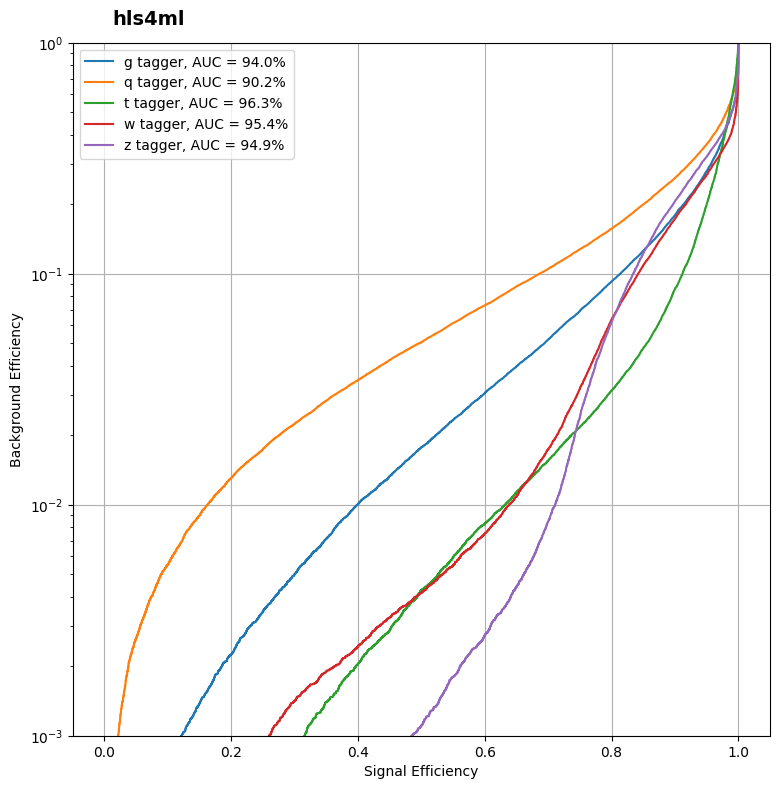

In [8]:
import plotting
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_keras = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)

An accuracy of ~75% is expected for this 5-class problem — random guessing gives only 20%, and some classes (notably gluon vs. light quark) are physically very similar and genuinely hard to separate even with more sophisticated methods.

The ROC (Receiver Operating Characteristic) curve shows, for each class, the trade-off between signal efficiency (true positive rate) and background efficiency (false positive rate) as the decision threshold is varied. The area under the curve (AUC) ranges from 0.5 (random classifier) to 1.0 (perfect). Higher and further to the upper-left is better.

**N.B.** This notebook trains a full-precision (32-bit floating-point) model. When converting to an FPGA design, hls4ml applies post-training quantization (PTQ) by default, which works well at 16-bit precision but struggles to match accuracy below ~8 bits. For the most resource-efficient FPGA designs **quantization-aware training (QAT)** gives substantially better results. See **Part 2** for QKeras (Keras) and Brevitas (PyTorch) QAT examples.

## Next step

Your model is trained and saved. Open **`1c_hls4ml_synth.ipynb`** to convert it to an FPGA design with hls4ml.

## Further reading

For more details, see: Duarte, Han, Harris et al., "Fast inference of deep neural networks in FPGAs for particle physics", JINST 13 P07027 (2018), [arXiv:1804.06913](https://arxiv.org/abs/1804.06913)